In [1]:
import numpy as np
from misc.dataset import get_data
from misc.helpers import normalizeRNA
from models.autoencoder import MLPAutoencoder
from models.dec import DEC
from models.metrics import calculate_metrics

data = get_data()  # loads + joins aak100_cpmdat.csv and MetaSheet_1_4.csv by sample_id
X = np.hstack([normalizeRNA(data['rnanp']), data['clin']]).astype(np.float32)
print(X.shape, data['label_classes'])

(166, 102) ['MGS1' 'MGS4']


In [2]:
ae = MLPAutoencoder(n_features=X.shape[1])
ae.build_model()
ae.train(X)

Epoch 25/500 - loss: 0.0573
Epoch 50/500 - loss: 0.0450
Epoch 75/500 - loss: 0.0420
Epoch 100/500 - loss: 0.0350
Epoch 125/500 - loss: 0.0307
Epoch 150/500 - loss: 0.0287
Epoch 175/500 - loss: 0.0238
Epoch 200/500 - loss: 0.0218
Epoch 225/500 - loss: 0.0199
Epoch 250/500 - loss: 0.0189
Epoch 275/500 - loss: 0.0181
Epoch 300/500 - loss: 0.0166
Epoch 325/500 - loss: 0.0153
Epoch 350/500 - loss: 0.0148
Epoch 375/500 - loss: 0.0141
Epoch 400/500 - loss: 0.0136
Epoch 425/500 - loss: 0.0131
Epoch 450/500 - loss: 0.0123
Epoch 475/500 - loss: 0.0120
Epoch 500/500 - loss: 0.0113


In [3]:
dec = DEC(ae, n_clusters=2)
y_pred, y_proba, centroids, z = dec.fit(X, y=data['y'])

acc, ari, nmi = calculate_metrics(data['y'], y_pred)
print('acc={:.3f}  ari={:.3f}  nmi={:.3f}'.format(acc, ari, nmi))

Iter 0: acc = 0.59639, nmi = 0.03090, ari = 0.03170 ; loss=0.00000
Iter 140: acc = 0.57831, nmi = 0.01806, ari = 0.01897 ; loss=0.02116
Iter 280: acc = 0.57831, nmi = 0.01806, ari = 0.01897 ; loss=0.02413
delta_label 0.0 < tol 0.01
performed 280 iterations.
Reached tolerance threshold. Stopping training.
Final: acc = 0.57831, nmi = 0.01806, ari = 0.01897 ; loss=0.02413
acc=0.578  ari=0.019  nmi=0.018


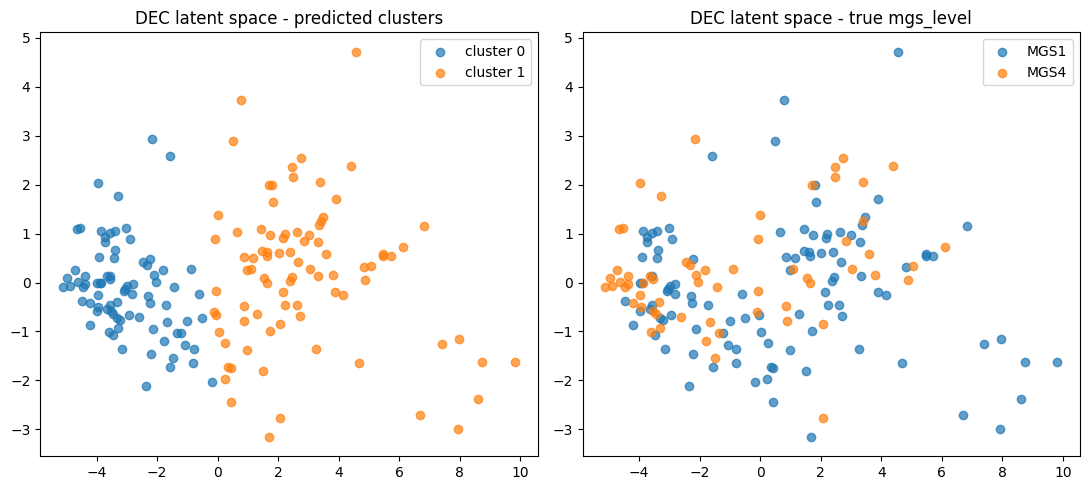

mgs_level  MGS1  MGS4
cluster              
0            45    36
1            60    25


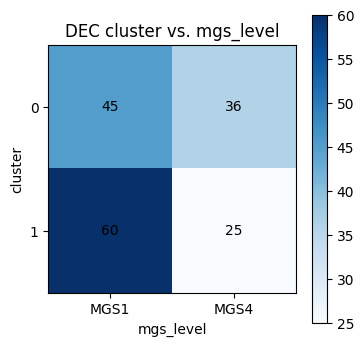

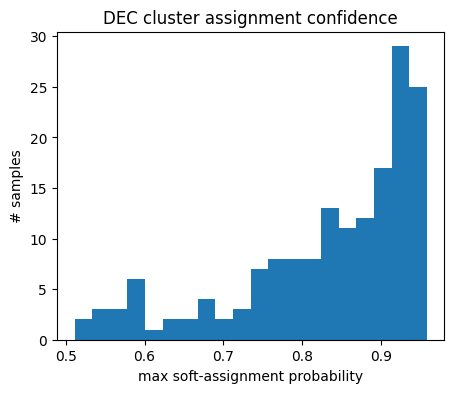

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA

# ---- 1. latent space, predicted cluster vs. true label ----
proj = PCA(n_components=2, random_state=5192).fit_transform(z)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for c in np.unique(y_pred):
    mask = y_pred == c
    axes[0].scatter(proj[mask, 0], proj[mask, 1], label=f'cluster {c}', alpha=0.7)
axes[0].set_title('DEC latent space - predicted clusters')
axes[0].legend()

for c, name in enumerate(data['label_classes']):
    mask = data['y'] == c
    axes[1].scatter(proj[mask, 0], proj[mask, 1], label=name, alpha=0.7)
axes[1].set_title('DEC latent space - true mgs_level')
axes[1].legend()
plt.tight_layout()
plt.show()

# ---- 2. cluster vs. label cross-tab heatmap ----
ct = pd.crosstab(pd.Series(y_pred, name='cluster'),
                 pd.Series(data['label_classes'][data['y']], name='mgs_level'))
print(ct)

fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(ct.values, cmap='Blues')
ax.set_xticks(range(len(ct.columns))); ax.set_xticklabels(ct.columns)
ax.set_yticks(range(len(ct.index))); ax.set_yticklabels(ct.index)
ax.set_xlabel('mgs_level'); ax.set_ylabel('cluster')
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        ax.text(j, i, ct.values[i, j], ha='center', va='center')
plt.colorbar(im)
plt.title('DEC cluster vs. mgs_level')
plt.show()

# ---- 3. assignment confidence ----
plt.figure(figsize=(5, 4))
plt.hist(y_proba.max(axis=1), bins=20)
plt.xlabel('max soft-assignment probability')
plt.ylabel('# samples')
plt.title('DEC cluster assignment confidence')
plt.show()